## Detección de *Data Leakage* entre los conjuntos de entrenamiento, validación y prueba

Este notebook surge a partir del análisis de los resultados obtenidos durante el entrenamiento de los distintos modelos desarrollados en el trabajo práctico. Si bien las métricas alcanzadas fueron muy satisfactorias, especialmente en los modelos de mayor capacidad, el comportamiento observado en algunas curvas de entrenamiento despertó la sospecha de que pudiera existir algún factor externo inflando el desempeño.

Luego de haber identificado y eliminado imágenes corruptas del dataset, decidimos verificar la existencia de **data leakage** entre los conjuntos de entrenamiento (*train*), validación (*valida*) y prueba (*test*). Este fenómeno ocurre cuando una misma muestra, o una copia idéntica de ella, aparece en más de uno de estos conjuntos, provocando que el modelo sea evaluado sobre imágenes que ya fueron utilizadas durante el entrenamiento.

Para comprobar esta hipótesis se calcularon los **hashes MD5** de todas las imágenes del dataset. El uso de esta técnica permite identificar archivos exactamente iguales independientemente de su ubicación dentro de la estructura de carpetas, ya que dos imágenes idénticas generan el mismo valor hash.

Los resultados confirmaron la presencia de imágenes compartidas entre los conjuntos de entrenamiento, validación y prueba. Este hallazgo resulta especialmente relevante, ya que compromete la independencia entre los conjuntos de datos y puede producir una sobreestimación del desempeño del modelo, reflejándose en métricas de evaluación artificialmente elevadas.

Este problema fue detectado una vez avanzado el desarrollo del trabajo práctico, por lo que los experimentos presentados fueron realizados sobre el dataset original. No obstante, como parte de este análisis se generó un nuevo conjunto de datos libre de duplicados (`dogs_clean.csv`), el cual constituye una versión más adecuada para repetir los experimentos y obtener una evaluación más confiable del rendimiento real de los modelos.

El objetivo de este notebook es documentar el procedimiento utilizado para detectar el *data leakage*, cuantificar el problema y dejar disponible una versión corregida del dataset para futuros experimentos.


## Equipo
- Alumno 1 : Almada Manuela
- Alumno 2 : Sanz Alfredo

## 1. Clonar el repositorio

Si tu fork es privado, genera un token de acceso (GitHub -> Settings -> Developer settings ->
Personal access tokens) y usalo en la URL, o sube un zip del proyecto a Colab/Drive.

In [ ]:
# TO-DO: completar con la URL de tu fork.
# Repo privado: https://<TOKEN>@github.com/<usuario>/tuia-dog-recognition-app.git
REPO_URL = "https://github.com/manuela-almada/tuia-dog-recognition-app.git"

!git clone $REPO_URL proyecto

Cloning into 'proyecto'...
remote: Enumerating objects: 209, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 209 (delta 30), reused 22 (delta 22), pack-reused 171 (from 1)
Receiving objects: 100% (209/209), 13.15 MiB | 15.94 MiB/s, done.
Resolving deltas: 100% (88/88), done.


In [ ]:
%cd proyecto
!ls

/content/proyecto/proyecto
data		    Dockerfile.frontend  models     requirements.txt  TP2.pdf
docker-compose.yml  etapa2_colab.ipynb	 output     scripts
Dockerfile	    informe.ipynb	 README.md  src


## 2. Instalar dependencias

Colab ya incluye torch, torchvision, opencv, numpy, scikit-learn y matplotlib;
solo se instala lo que falta.

In [ ]:
!pip install -q pydantic-settings python-dotenv kagglehub albumentations

## 3. Descargar el dataset

In [ ]:
import albumentations
import kagglehub
from pydantic_settings import BaseSettings

print("OK")

OK


In [ ]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from lib.config import settings

import torch
print("dataset_path:", settings.dataset_path)
print("GPU disponible:", torch.cuda.is_available())

dataset_path: data/dataset
GPU disponible: True


In [ ]:
from __future__ import annotations
from email.mime import image

#------------------------------------------------------------------
import torch
from torch import nn
from torchvision.models import resnet18, ResNet18_Weights
#------------------------------------------------------------------

import json
import logging
from pathlib import Path
from typing import Callable, Optional
from uuid import uuid4

import cv2
import numpy as np

from lib.schemas import EmbeddingRecord, Neighbor, SearchResult
from lib.storage.base import EmbeddingStoreProtocol

logger = logging.getLogger(__name__)

print("Imports OK")

Imports OK


In [ ]:
!python scripts/download_dataset.py
!ls data/dataset

Descargando gpiosenka/70-dog-breedsimage-data-set ...
Using Colab cache for faster access to the '70-dog-breedsimage-data-set' dataset.
Dataset disponible en /content/proyecto/proyecto/data/dataset
dogs.csv  test	train  valid


## 4. Analisis del dataset

TO-DO:
- Analizar la distribucion de clases y documentar la cantidad de imagenes por raza.
- Definir los conjuntos de entrenamiento, validacion y prueba.
- Filtrar imagenes de baja calidad (documentar el criterio).

### Análisis del dataset completo

In [ ]:
import pandas as pd

dogs_csv = pd.read_csv('./data/dataset/dogs.csv')
dogs_csv['labels'] = dogs_csv['labels'].str.strip().str.replace(r'\s+', ' ', regex=True)

img_x_raza = dogs_csv['labels'].value_counts()

print(f"Cantidad de imágenes: {len(dogs_csv)}")
print(f"Cantidad de razas: {len(img_x_raza)}")
print(f"Cantidad mínima de imágenes por raza: {img_x_raza.min()}")
print(f"Cantidad máxima de imágenes por raza: {img_x_raza.max()}")
print(f"Cantidad promedio de imágenes por raza: {img_x_raza.mean()}")
print(f"Desviación estándar de imágenes por raza: {img_x_raza.std()}")

Cantidad de imágenes: 9346
Cantidad de razas: 70
Cantidad mínima de imágenes por raza: 85
Cantidad máxima de imágenes por raza: 218
Cantidad promedio de imágenes por raza: 133.5142857142857
Desviación estándar de imágenes por raza: 24.68335286995451


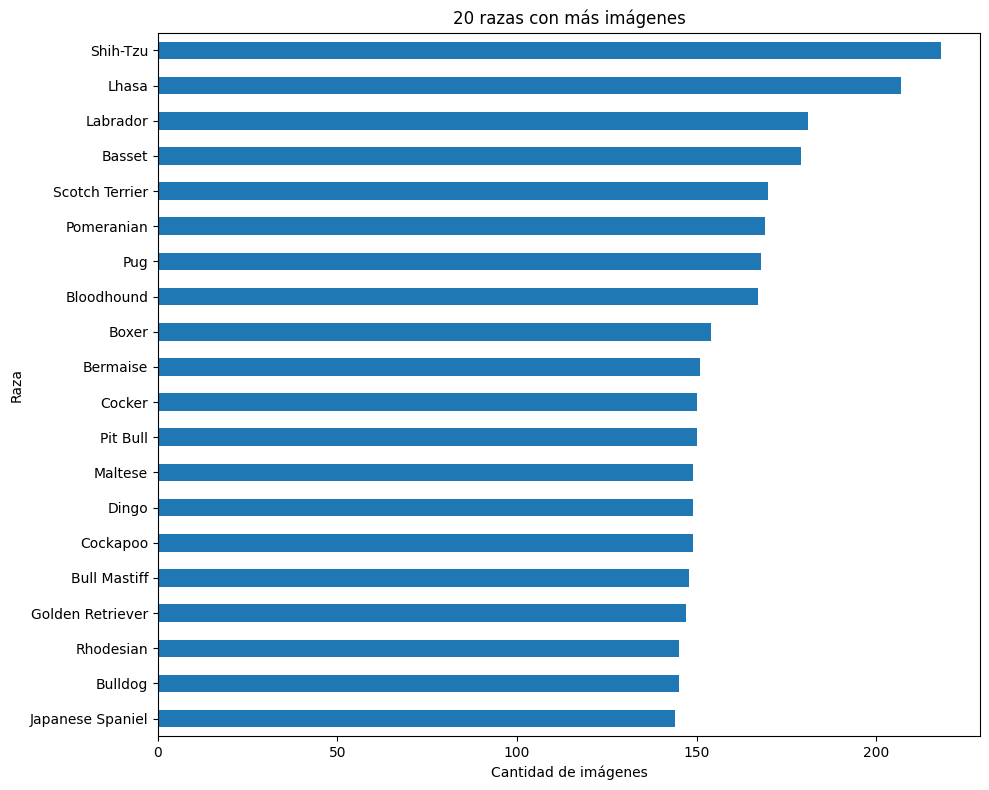

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

img_x_raza.head(20).sort_values().plot(kind="barh")

plt.title("20 razas con más imágenes")
plt.xlabel("Cantidad de imágenes")
plt.ylabel("Raza")
plt.tight_layout()
plt.show()

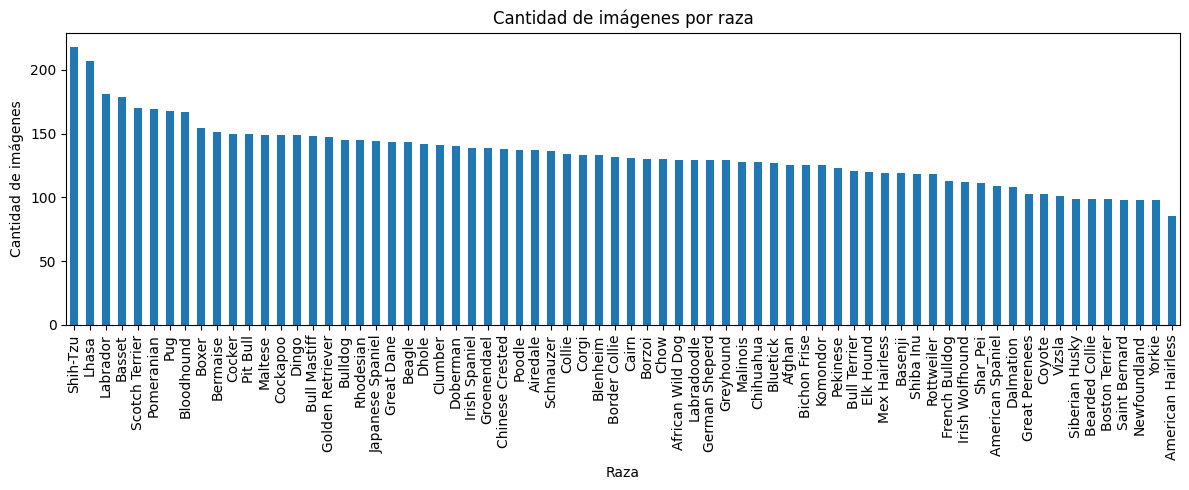

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
img_x_raza.sort_values(ascending=False).plot(kind='bar')
plt.title('Cantidad de imágenes por raza')
plt.xlabel('Raza')
plt.ylabel('Cantidad de imágenes')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Partimos de un dataset compuesto por 9346 imágenes, distribuídas en un total de 70 razas de perros (sin considerar aún la partición en conjuntos de entrenamiento, validación y testeo). La cantidad de imágenes por raza varía entre 85 y 218, con un promedio aproximado de 133 imágenes por clase.

Por otro lado, el desvío estándar es de 24,68 imágenes, lo que indica una dispersión moderada en la distribución de ejemplos entre las distintas razas. Esto sugiere que, el dataset no presenta un desbalance extremo


### Entrenamiento, validación y prueba

In [ ]:
print(dogs_csv['data set'].unique())

['train' 'test' 'valid']


In [ ]:
train_df= dogs_csv[dogs_csv['data set']=='train'].copy()
val_df= dogs_csv[dogs_csv['data set']=='valid'].copy()
test_df= dogs_csv[dogs_csv['data set']=='test'].copy()

print('Split de conjuntos predefinido:')
print(f"Cantidad de imágenes de entrenamiento: {len(train_df)}")
print(f"Cantidad de imágenes de validación: {len(val_df)}")
print(f"Cantidad de imágenes de prueba: {len(test_df)}")

Split de conjuntos predefinido:
Cantidad de imágenes de entrenamiento: 7946
Cantidad de imágenes de validación: 700
Cantidad de imágenes de prueba: 700


In [ ]:
razas_train = set(train_df['labels'])
razas_val = set(val_df['labels'])
razas_test = set(test_df['labels'])

print("Cantidad de razas en Train:", len(razas_train))
print("Cantidad de razas en Val:", len(razas_val))
print("Cantidad de razas en Test:", len(razas_test),)

print("Verificamos si todas las razas están presentes en todos los conjuntos")
print("Train pero no Val:", razas_train - razas_val)
print("Train pero no Test:", razas_train - razas_test)
print("Val pero no Train:", razas_val - razas_train)
print("Test pero no Train:", razas_test - razas_train)

Cantidad de razas en Train: 70
Cantidad de razas en Val: 70
Cantidad de razas en Test: 70
Verificamos si todas las razas están presentes en todos los conjuntos
Train pero no Val: set()
Train pero no Test: set()
Val pero no Train: set()
Test pero no Train: set()


Considerando la partición predeterminada definida en dogs.csv, observamos que la mayor parte de las imágenes se encuentra en el conjunto de entrenamiento (7.946 imágenes). Por su parte, los conjuntos de validación y prueba contienen una cantidad significativamente menor de ejemplos, con 700 imágenes cada uno.

Asimismo, se verificó que las 70 razas del dataset están representadas en los tres conjuntos (train, validation y test). Esto garantiza que todas las clases estarán presentes tanto durante el entrenamiento como en las etapas de validación y evaluación, permitiendo analizar el desempeño del modelo sobre la totalidad de las razas incluidas en el dataset.

Cantidad mínima de imágenes por raza en Train: 65
Cantidad máxima de imágenes por raza en Train: 198
Ratio entre mínimo y máximo de imágenes por raza en Train: 3.046153846153846
Media de imágenes por raza en Train: 113.51428571428572
Desviación estándar de imágenes por raza en Train: 24.683352869954515
Coeficiente de variación de imágenes por raza en Train: 0.21744710557473143


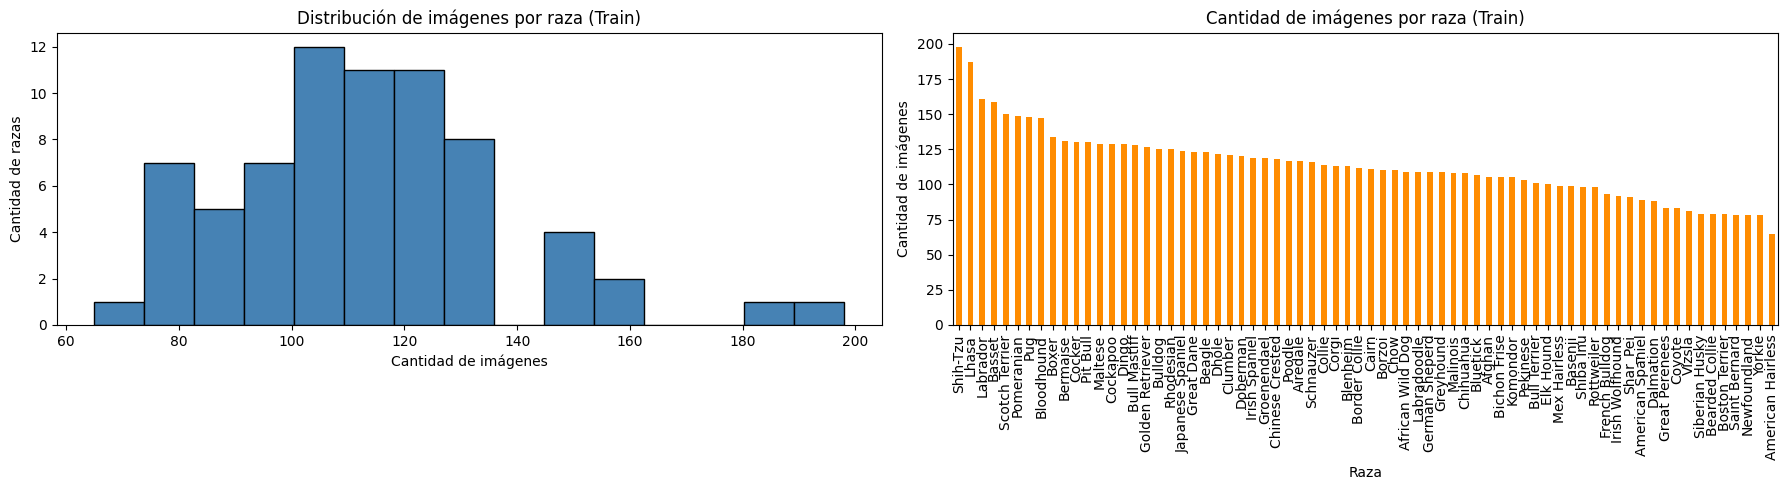

In [ ]:
img_x_raza_train = train_df['labels'].value_counts()

max_train = img_x_raza_train.max()
min_train = img_x_raza_train.min()

ratio_min_max_train = max_train / min_train

media_train= img_x_raza_train.mean()
desvio_train = img_x_raza_train.std()

cv_train = desvio_train/ media_train

print(f"Cantidad mínima de imágenes por raza en Train: {min_train}")
print(f"Cantidad máxima de imágenes por raza en Train: {max_train}")
print(f"Ratio entre mínimo y máximo de imágenes por raza en Train: {ratio_min_max_train}")
print(f"Media de imágenes por raza en Train: {media_train}")
print(f"Desviación estándar de imágenes por raza en Train: {desvio_train}")
print(f"Coeficiente de variación de imágenes por raza en Train: {cv_train}")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Histograma
axes[0].hist(
    img_x_raza_train.values,
    bins=15,
    color='steelblue',
    edgecolor='black'
)

axes[0].set_title("Distribución de imágenes por raza (Train)")
axes[0].set_xlabel("Cantidad de imágenes")
axes[0].set_ylabel("Cantidad de razas")

# Barras
img_x_raza_train.sort_values(ascending=False).plot(
    kind='bar',
    ax=axes[1],
    color='darkorange'
)

axes[1].set_title("Cantidad de imágenes por raza (Train)")
axes[1].set_xlabel("Raza")
axes[1].set_ylabel("Cantidad de imágenes")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

El conjunto de entrenamiento merece un análisis particular, ya que constituye la base sobre la cual el modelo aprenderá las representaciones de las distintas razas. En nuestro caso, además, estas imágenes serán utilizadas para generar los embeddings que conformarán la base de datos vectorial, por lo que la calidad y representatividad de este conjunto tendrán un impacto directo en el desempeño de las búsquedas por similitud.

A partir de las métricas calculadas, observamos que el conjunto presenta un desbalance moderado entre clases. La cantidad de imágenes por raza varía entre 65 y 198 ejemplos, con un coeficiente de variación de 0,21, y un ratio entre max y min que nos informa que la clase con mayor cantidad de elementos tiene aproximadamente 3.4 veces más imágenes que la clase minoritaria. Si bien existen diferencias en la representación de las distintas razas, estas no resultan extremas y sugieren una distribución relativamente homogénea.

Esta observación se ve respaldada por las visualizaciones obtenidas. El histograma muestra que la mayor concentración de clases se encuentra en torno al valor medio (aproximadamente 130 imágenes por raza), aunque también se identifican otros grupos de frecuencias que evidencian cierta heterogeneidad en la distribución. Por su parte, el gráfico de barras permite apreciar las diferencias en la cantidad de muestras disponibles para cada clase, confirmando que algunas razas cuentan con una representación significativamente mayor que otras.

El estudio del balance de clases resulta fundamental, ya que una distribución desigual puede favorecer el aprendizaje de las clases más representadas y dificultar la correcta identificación de aquellas con menor cantidad de ejemplos. Sin emargo teniendo en cuenta el "tamaño" del desbalance, se optó únicamente por monitoriar métricas representativas en este tipo de datasets (como lo es F1-score).


### ¿Qué imagenes filtramos? ¿Con qué criterio?

Criterio 1: integridad del dataset.

Aquellas imágenes que no puedan abrirse correctamente no serán utilizadas en este proceso ya que no será posible acceder a la información presente en las mismas.

In [ ]:
from PIL import Image
from pathlib import Path

image_dir = Path("./data/dataset")

imagenes_corruptas = []
total_imagenes = 0

for img_path in image_dir.rglob("*"):

    if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
        continue

    total_imagenes += 1

    try:
        with Image.open(img_path) as img:
            img.verify()

    except Exception:
        imagenes_corruptas.append(str(img_path))

print(f"Total de imágenes: {total_imagenes}")
print(f"Imágenes corruptas: {len(imagenes_corruptas)}")



Total de imágenes: 9346
Imágenes corruptas: 0


Criterio 2: Data Leakage.

Aquellas imágenes que se encuentren duplicadas en conjuntos de entrenamiento, validación y testeo se consideraran únicamente las presentes en train, el resto serán descartadas

In [ ]:
import hashlib

def calcular_hash(path):
  """
  Hash MD5:  sirve para crear una huella digital única (llamada hash) a partir de cualquier archivo o texto.
  Una de sus funciones principales es Identificación de datos:
  Compara grandes volúmenes de información de manera rápida detectando archivos duplicados mediante sus resúmenes.
  """
  with open(path, "rb") as f:
    return hashlib.md5(f.read()).hexdigest()

In [ ]:
hashes = {}
leakages = []

for _, row in dogs_csv.iterrows():

    img_path = Path("./data/dataset") / row["filepaths"]
    split = row["data set"]

    h = calcular_hash(img_path)

    if h not in hashes:
        hashes[h] = []

    hashes[h].append({
        "path": str(img_path),
        "split": split
    })


for h, imgs in hashes.items():

    splits = {img["split"] for img in imgs}

    if len(splits) > 1:

        leakages.append({
            "hash": h,
            "splits": splits,
            "imagenes": imgs
        })

print("Posibles casos de data leakage:", len(leakages))

Posibles casos de data leakage: 66


In [ ]:
for caso in leakages[:5]:

    print("Splits involucrados:", caso["splits"])

    for img in caso["imagenes"]:
        print("   ", img["split"], img["path"])
    print()

Splits involucrados: {'test', 'train'}
    train data/dataset/train/Afghan/016.jpg
    test data/dataset/test/Afghan/03.jpg

Splits involucrados: {'test', 'train'}
    train data/dataset/train/Afghan/022.jpg
    test data/dataset/test/Afghan/04.jpg

Splits involucrados: {'test', 'train'}
    train data/dataset/train/Airedale/102.jpg
    test data/dataset/test/Airedale/09.jpg

Splits involucrados: {'test', 'valid', 'train'}
    train data/dataset/train/Bichon Frise/066.jpg
    train data/dataset/train/Bichon Frise/072.jpg
    test data/dataset/test/Bichon Frise/02.jpg
    valid data/dataset/valid/Bichon Frise/01.jpg

Splits involucrados: {'test', 'train'}
    train data/dataset/train/Bichon Frise/069.jpg
    test data/dataset/test/Bichon Frise/04.jpg



Hash: 465db00cdf34bf5b435837608e4800b6
Splits involucrados: {'test', 'train'}


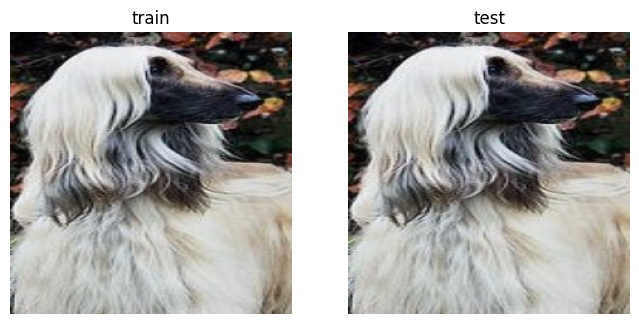

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Tomamos un caso con leakage
ejemplo = leakages[0]

print("Hash:", ejemplo["hash"])
print("Splits involucrados:", ejemplo["splits"])

imagenes = ejemplo["imagenes"]

n = len(imagenes)
plt.figure(figsize=(4 * n, 4))

for i, img in enumerate(imagenes):
    path = img["path"]
    split = img["split"]

    image = Image.open(path)

    plt.subplot(1, n, i + 1)
    plt.imshow(image)
    plt.title(f"{split}")
    plt.axis("off")

plt.show()

In [ ]:
from collections import Counter

contador = Counter()

for caso in leakages:
    clave = tuple(sorted(caso["splits"]))
    contador[clave] += 1
print('Duplicados entre:')
for clave, cantidad in contador.items():
    print(clave, "->", cantidad)


Duplicados entre:
('test', 'train') -> 31
('test', 'train', 'valid') -> 2
('train', 'valid') -> 29
('test', 'valid') -> 4


Uno de los aspectos más importantes a verificar al trabajar con conjuntos de entrenamiento, validación y prueba es la ausencia de **data leakage**. Este fenómeno ocurre cuando información que debería permanecer aislada entre los distintos conjuntos termina siendo compartida entre ellos, permitiendo que el modelo tenga acceso durante el entrenamiento a ejemplos que posteriormente serán utilizados para su evaluación.

La presencia de data leakage conduce a una sobreestimación del desempeño real del modelo, ya que las métricas obtenidas dejan de reflejar su capacidad de generalización sobre datos no vistos. Una analogía sencilla consiste en pensar en un estudiante al que se le entrega parte de las respuestas antes de rendir un examen: una buena calificación en esas condiciones no necesariamente indica comprensión del tema, sino que puede ser consecuencia de haber memorizado información previamente conocida. De manera similar, los modelos de aprendizaje automático poseen una gran capacidad para memorizar patrones presentes en los datos de entrenamiento, por lo que la existencia de ejemplos duplicados entre conjuntos puede inflar artificialmente las métricas de evaluación.

Para detectar posibles casos de data leakage se realizó un análisis de imágenes duplicadas mediante hashes MD5, considerando que dos archivos con el mismo hash corresponden a imágenes idénticas. Los resultados obtenidos evidenciaron la presencia de duplicados entre los distintos conjuntos:

* 31 grupos de imágenes duplicadas entre entrenamiento y prueba. (31 hashes compartidos)
* 29 grupos de imágenes duplicadas entre entrenamiento y validación. (29 hashes compartidos)
* 4 grupos de imágenes duplicadas entre validación y prueba.(4 hashes compartidos)
* 2 grupos de imágenes duplicadas presentes simultáneamente en entrenamiento, validación y prueba. (2 hashes compartidos)

Estos resultados ponen de manifiesto la existencia de data leakage en el dataset original, por lo que resulta necesario eliminar o reasignar las imágenes duplicadas antes de continuar con la creación de la base de datos y su posterior evaluación. De esta manera se garantiza que las métricas obtenidas reflejen de forma más fiel la capacidad real de generalización del sistema.



In [ ]:
imagenes_a_eliminar = []

for h, imgs in hashes.items():

    if len(imgs) == 1:
        continue

    train_imgs = [img for img in imgs if img["split"] == "train"]
    valid_imgs = [img for img in imgs if img["split"] == "valid"]
    test_imgs  = [img for img in imgs if img["split"] == "test"]

    if train_imgs:

        # conservar la primera de train
        conservar = train_imgs[0]["path"]

        for img in imgs:

            if img["path"] != conservar:
                imagenes_a_eliminar.append(img["path"])

    elif valid_imgs:

        conservar = valid_imgs[0]["path"]

        for img in imgs:

            if img["path"] != conservar:
                imagenes_a_eliminar.append(img["path"])

    else:

        conservar = test_imgs[0]["path"]

        for img in imgs:

            if img["path"] != conservar:
                imagenes_a_eliminar.append(img["path"])

print(len(imagenes_a_eliminar))

119


**Nuestra estrategia:**

Si existe alguna copia en train:
* Conservamos una sola copia en train.
* Eliminamos todas las demás.

Si no existe train pero existe valid:
* Conservamos una sola copia en valid.
* Eliminamos todas las demás.

Si sólo existe test:
* Conservamos una sola copia en test.
* Eliminamos todas las demás.

De este modo desaparecen los duplicados internos de cada conjunto y los percibidos entre conjuntos (data leakaged)

In [ ]:
#Cambiamos el formato para hacerlo compatible con 'filepaths' de dogs_csv
imagenes_a_eliminar_csv = [
    path.replace("data/dataset/", "")
    for path in imagenes_a_eliminar
]
imagenes_a_eliminar_csv

['test/Afghan/03.jpg',
 'test/Afghan/04.jpg',
 'train/Airedale/013.jpg',
 'train/Airedale/021.jpg',
 'test/Airedale/09.jpg',
 'train/Bichon Frise/088.jpg',
 'train/Bichon Frise/072.jpg',
 'test/Bichon Frise/02.jpg',
 'valid/Bichon Frise/01.jpg',
 'test/Bichon Frise/04.jpg',
 'test/Border Collie/02.jpg',
 'test/Border Collie/03.jpg',
 'test/Border Collie/06.jpg',
 'valid/Border Collie/05.jpg',
 'train/Boxer/034.jpg',
 'train/Boxer/083.jpg',
 'test/Boxer/01.jpg',
 'train/Bull Mastiff/010.jpg',
 'train/Bull Mastiff/037.jpg',
 'train/Bull Mastiff/036.jpg',
 'test/Bull Mastiff/06.jpg',
 'train/Bull Mastiff/042.jpg',
 'train/Bull Mastiff/046.jpg',
 'train/Bulldog/042.jpg',
 'test/Bulldog/09.jpg',
 'test/Chihuahua/04.jpg',
 'valid/Chinese Crested/05.jpg',
 'valid/Chinese Crested/06.jpg',
 'valid/Chinese Crested/07.jpg',
 'valid/Chinese Crested/08.jpg',
 'valid/Chinese Crested/09.jpg',
 'valid/Chinese Crested/10.jpg',
 'train/Clumber/018.jpg',
 'train/Clumber/039.jpg',
 'train/Clumber/047.jpg'

In [ ]:
dogs_csv_limpio = dogs_csv[
    ~dogs_csv["filepaths"].isin(imagenes_a_eliminar_csv)].copy()

print("Original:", len(dogs_csv))
print("Limpio:", len(dogs_csv_limpio))
print("Eliminadas:", len(dogs_csv) - len(dogs_csv_limpio))

interseccion = set(dogs_csv_limpio["filepaths"]) & set(imagenes_a_eliminar_csv)
print("Interseccion los paths a eliminar y el conjunto final (debería ser 0):", len(interseccion))

dogs_csv_limpio.to_csv(
    "dogs_clean.csv",
    index=False)
dogs_csv_limpio

Original: 9346
Limpio: 9227
Eliminadas: 119
Interseccion los paths a eliminar y el conjunto final (debería ser 0): 0


,filepaths,labels,data set
0,train/Afghan/001.jpg,Afghan,train
1,train/Afghan/002.jpg,Afghan,train
2,train/Afghan/003.jpg,Afghan,train
3,train/Afghan/004.jpg,Afghan,train
4,train/Afghan/005.jpg,Afghan,train
...,...,...,...
9341,valid/Yorkie/06.jpg,Yorkie,valid
9342,valid/Yorkie/07.jpg,Yorkie,valid
9343,valid/Yorkie/08.jpg,Yorkie,valid
9344,valid/Yorkie/09.jpg,Yorkie,valid


Con el nuevo conjunto de datos repetimos análisis por conjunto *(train/valid/test)*:

In [ ]:
dogs_csv_limpio= pd.read_csv('./dogs_clean.csv')
train_df= dogs_csv_limpio[dogs_csv_limpio['data set']=='train'].copy()
val_df= dogs_csv_limpio[dogs_csv_limpio['data set']=='valid'].copy()
test_df= dogs_csv_limpio[dogs_csv_limpio['data set']=='test'].copy()

print('Split de conjuntos predefinido:')
print(f"Cantidad de imágenes de entrenamiento post-limpieza: {len(train_df)}")
print(f"Cantidad de imágenes de validación post-limpieza: {len(val_df)}")
print(f"Cantidad de imágenes de prueba  post-limpieza: {len(test_df)}")

Split de conjuntos predefinido:
Cantidad de imágenes de entrenamiento post-limpieza: 7900
Cantidad de imágenes de validación post-limpieza: 668
Cantidad de imágenes de prueba  post-limpieza: 659


Cantidad mínima de imágenes por raza en Train: 65
Cantidad máxima de imágenes por raza en Train: 197
Ratio entre mínimo y máximo de imágenes por raza en Train: 3.0307692307692307
Media de imágenes por raza en Train: 112.85714285714286
Desviación estándar de imágenes por raza en Train: 23.944552927687592
Coeficiente de variación de imágenes por raza en Train: 0.21216692467571283


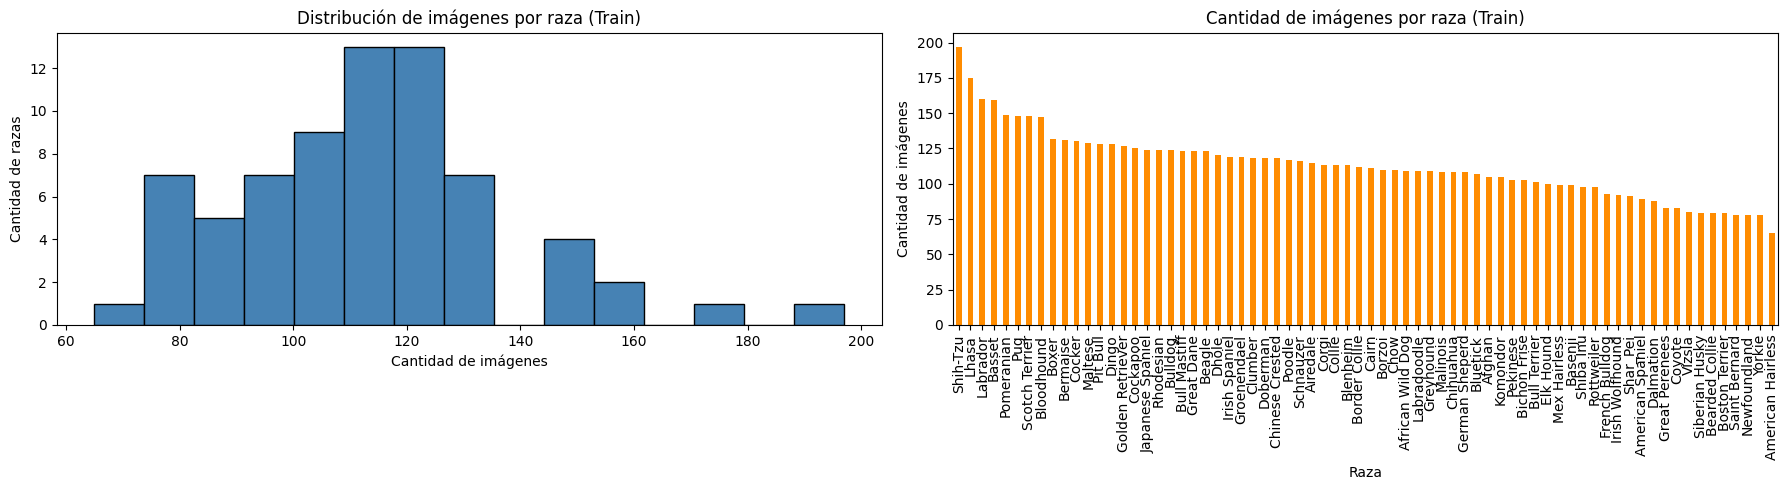

In [ ]:
img_x_raza_train = train_df['labels'].value_counts()

max_train = img_x_raza_train.max()
min_train = img_x_raza_train.min()

ratio_min_max_train = max_train / min_train

media_train= img_x_raza_train.mean()
desvio_train = img_x_raza_train.std()

cv_train = desvio_train/ media_train

print(f"Cantidad mínima de imágenes por raza en Train: {min_train}")
print(f"Cantidad máxima de imágenes por raza en Train: {max_train}")
print(f"Ratio entre mínimo y máximo de imágenes por raza en Train: {ratio_min_max_train}")
print(f"Media de imágenes por raza en Train: {media_train}")
print(f"Desviación estándar de imágenes por raza en Train: {desvio_train}")
print(f"Coeficiente de variación de imágenes por raza en Train: {cv_train}")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Histograma
axes[0].hist(
    img_x_raza_train.values,
    bins=15,
    color='steelblue',
    edgecolor='black'
)

axes[0].set_title("Distribución de imágenes por raza (Train)")
axes[0].set_xlabel("Cantidad de imágenes")
axes[0].set_ylabel("Cantidad de razas")

# Barras
img_x_raza_train.sort_values(ascending=False).plot(
    kind='bar',
    ax=axes[1],
    color='darkorange'
)

axes[1].set_title("Cantidad de imágenes por raza (Train)")
axes[1].set_xlabel("Raza")
axes[1].set_ylabel("Cantidad de imágenes")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Tras la depuración de los datos encontramos que las métricas del conjunto prácticamente no varían, esto se debe a que priorizamos mantener las imágenes en este conjunto, por este motivo es que perdimos pocas imágenes.